# Tuesday March 24th 2026

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
%matplotlib widget
from ipywidgets import interact

# Chapter 12: scipy

Whereas we learn how to compute derivatives, integrals, solve equations, etc. in math class, in reality, most functions are too complicated to be integrated exactly. and most equations cannot be solved using pen and paper.

Consider the seemingly simple problem of computing $I = \int_0^1 e^{-x^2}\, dx$. It is clear that $I$ exists, but it cannot be computed using the fundamental theorem of calculus, because the antiderivative of $e^{-x^2}$ cannot be expressed in terms of classical functions like polynomials, trigonometric functions, exponential and logarithms.

The branches of mathematics, *numerical analysis*, and *scientific computing* are concerned with creating algorithms to approximate the solution of problems that cannot be solved exactly, or solve problems that are too complicated to be tackled by hand. 
. For instance, the trapezoidal and midpoint rules which we have encountered in several occasions could be used to compute an approximate value of $I$ within an arbitrary precision.

Many classical algorithms in numerical analysis and scientific computing are implemented in the `scipy` python module. We will focus on four areas of `scipy`: integration, differentiation, optimization, and linear algebra.

## 12.1 Integration: `scipy.integrate`

scipy offers 2 family of functions to compute definite integrals of functions of a single variable $\int_a^b f(x)\, dx$ depending on whether the integrand is a full python function (*i.e.* we can compute $f(x)$ for any $x$) or we know it only at a given fixed points (*i.e.* we have arrays `X` and `Y = f[X]`).

The general method for the former case is `quad` and that of the later is `trapezoid`.

### `scipy.integrate.quad`

* Basic calling scheme: `res, err = scipy.integrate.quad(f,a,b)`. This will return an approximation of the integral and an *estimate* of the accuracy of the approximation.
* One can control the accuracy of integration using the `epsabs` and `epsrel` optional arguments and `quad` will try to return a result satisfying ``abs(I-result) <= max(epsabs, epsrel*abs(I))``, `I` denoting the (unknown) exact value of the integral.
* For functions depending on parameters, one can either use a lambda function or the `args=()` optional argument.
* `scipy.integrate.quad` can compute *some* improper integrals (see the discussion on accuracy later) using `np.inf` as one of the integration bounds.

In [ ]:
def f(x):
    return np.sin(x)
print(scipy.integrate.quad(f,0,np.pi))

In [ ]:
plt.close('all')
def g(x,a):
    return np.sinc(x/a)

fig, ax = plt.subplots()
def plot(a,l):
    A = scipy.integrate.quad(lambda x : g(x,a), -l, l)[0]
    X = np.linspace(-4*np.pi,4*np.pi,201)
    ax.cla()
    ax.plot(X,g(X,a), label = f'a={a}')
    Xl = np.linspace(-l, l, 201)
    ax.fill_between(Xl,g(Xl,a),color='red', alpha=.5)
    ax.annotate(f'Area ~ {A:.2f}', xy=(0, 0.5), xytext=(5, 0.75))
    ax.legend()
    ax.grid()

interact(plot, a = (0.1, 10, 0.05), l = (0, 4*np.pi, 4*np.pi/100))


In [ ]:
plt.close('all')
A = np.linspace(0.11,1,100)
err = np.array([scipy.integrate.quad(lambda x : g(x,a), -3*np.pi,3*np.pi)[1] for a in A])

plt.plot(A,err)
plt.title("Choice of a vs. error")
plt.xlabel("a value")
plt.ylabel("Error")
plt.grid()
plt.show()


### Improper integrals

In scipy we can also compute improper integrals, here we are using the fact that numpy has an "infinite" floating point number.

In [ ]:
# Computing improper integrals
def f1(x):
    return 1/x**2
def f2(x):
    return 1/np.sqrt(x)
print(scipy.integrate.quad(f1,1,np.inf))
print(scipy.integrate.quad(f2,0,1))

### Recall - Diverging integral
The integral, 
$$\int_1^\infty \frac{1}{x}dx$$
diverges.

In [ ]:
# Example of quad rightfully failing to compute a diverging integral
def f3(x):
    return 1/x
print(scipy.integrate.quad(f3,1,np.inf))

In [ ]:
# An example of quad failing to compute a perfectly good (but slow converging) improper integral
def f4(x):
    return np.sin(x)**2/x**2

X = np.linspace(-4*np.pi,4*np.pi,201)
fig, ax = plt.subplots()
for a in (1, 2, 3):
    ax.plot(X,f4(X))
ax.grid()
# notice that 0 <= (sin(x)/x)**2 < 1/x**2 so that by the squeeze theorem, the integral of f4 from 1 to infinity should converge 
print(scipy.integrate.quad(f4,1,np.inf))

### Warning: don't always trust the computers...

Let $f(x) = e^{-x^2}$ (**Hint:** This function has a special name!). We have that 
$$\int_{-\infty}^\infty f(x)\, dx = \sqrt{\pi}.$$
We would therefore expect that when computing $\int_{-b}^b f(x)\, dx$, `quad` would return an increasingly better approximation of $\sqrt{\pi}$ as $b \to \infty$.

In [ ]:
np.sqrt(np.pi)

In [ ]:
## Warning, 
def f5(x):
    return np.exp(-x**2)
for b in (1, 10, 100, 1000, 10000):
    I = scipy.integrate.quad(f5,-b,b)
    print(f'b: {b}, computed integral: {I[0]:.4e}, estimated error {I[1]:.2e} error {abs(I[0]-np.sqrt(np.pi))/np.sqrt(np.pi):.2e}')


What happens is that the since $e^{-x^2}$ decays so quickly from $x=0$, the quadrature algorithm used by `quad` does not detect the fact that it has a peak near 0, when using a numerical quadrature formula on a large interval.

## 12.2 Integration again trapezoidal and Simpson rules

In many situations, one may want to estimate the integral of a function that is only known at some given points.
`scipy.integrate` can help here too. It implements the trapezoidal and Simpson's rules, which relies respectively on linear and quadratic approximation of a function on an interval.

* Basic calling sequence: `scipy.integrate.trapezoid(Y, X)` or `scipy.integrate.simpson(Y, X)`
* Note that in order to apply the trapezoidal or Simpson rule, one does not need the location of the sampling points, but only their spacing. For equi-distributed sampling points, one can pass `dx=` instead of `X` as an argument.

In [ ]:
n = 51
X = np.linspace(0,np.pi,n)
Y = np.sin(X)
print(scipy.integrate.trapezoid(Y,X))
print(scipy.integrate.simpson(Y,X))

dx = np.pi / (n-1)
print(scipy.integrate.trapezoid(Y,dx = dx))
print(scipy.integrate.simpson(Y,dx = dx))

The ability to pass non-equidistributed points can be used in two ways.
   - When the values of `Y` are not known at equi-distributed points.
   - In order to improve the accuracy of integration, when one knows something about the function to be integrated (recall the issue with $\int_0^b e^{-x^2}\, dx$ for large `b`).

In [ ]:
n = 5
nint = 100
Ith= np.sqrt(np.pi)/2
for n in range(n):
    print(f'\n Integrating exp(-x^2) on (0,{10**n})')
    Xlog = np.logspace(-9,n,nint)
    # np.logspace returns points whose log is equi-distributed (i.e. with spacing increasing exponentially)

    X = np.linspace(0,10**n,nint)

    print(f'* Simpson with {nint} logspaced sampling points')
    I = scipy.integrate.simpson(f5(Xlog),Xlog)
    print(f'  result: {I:3.5e}, error = {abs(I-Ith):3.5e}')

    print(f'* Simpson with {nint} equidistributed sampling points')
    I = scipy.integrate.simpson(f5(X),X)
    print(f'  result: {I:3.5e}, error = {abs(I-Ith):3.5e}')

    print(f'* scipy.integrate.quad')
    I,err = scipy.integrate.quad(f5,0,10**n)
    print(f'  result: {I:3.5e}, error = {abs(I-Ith):3.5e}')


# Thursday March 26th, 2026

### Announcements
- Assignment 5 posted due on April 2nd 2026 at 11:59pm

In [5]:
%matplotlib widget
import numpy as np
import scipy
import matplotlib.pyplot as plt

## 12.3  Application: Fourier series

In the early XIXth century, Joseph Fourier proved that "any" periodic function on an interval $(-p,p)$ can be represented by an infinite series of $cos$ and $sin$ of the form:
$$
f(x) = \frac{a_0}{2} + \sum_{n=1}^\infty a_n \cos\left(\tfrac{n\pi}{p}x\right) + b_n \sin \left(\tfrac{n\pi}{p}x\right),
$$
where 
$$ 
a_n = \frac{1}{p}\int_{-p}^p f(x) \cos\left(\tfrac{n\pi}{p}x\right)\, dx
$$
and 
$$ 
b_n = \frac{2}{p}\int_{-p}^p f(x) \sin\left(\tfrac{n\pi}{p}x\right)\, dx
$$

### Example
![FourierExample](PianoFourier.png)
![FourierExample2](MRIFourier.jpg)

Let's illustrate this when $f$ is a periodic function with period 2 such that 
$$
f(x) = \begin{cases}
1+x & \text{ if } -1 <x\le0\\
1 & \text{ if } 0 < x \le 1/2\\
-2(x-1) & \text{ if } 1/2 < x \le 1.
\end{cases}
$$

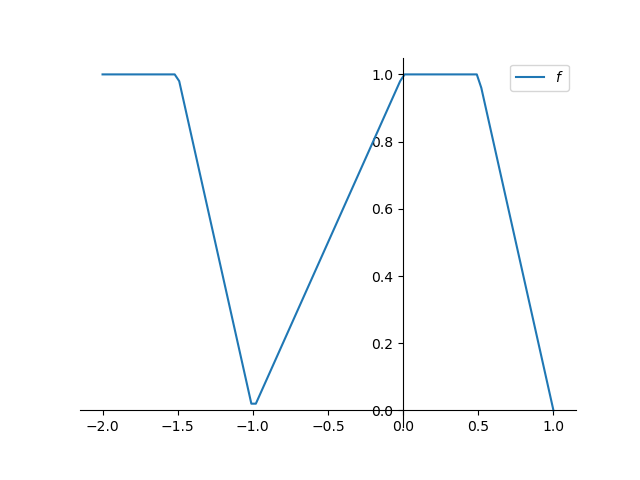

In [6]:
def f(x):
    y = (x-1)%2-1
    if y < 0:
        return 1+y
    elif y < 0.5:
        return 1
    else:
        return -2*(y-1)

fig, ax = plt.subplots()
X = np.linspace(-2.,1.,101)
ax.plot(X,[f(x) for x in X], label = '$f$')
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.legend()

In [7]:
def FourierCoefs(f, p, N):
    ''' 
    Returns the N first coefficients of the Fourier expansion of f on (-p,p)
    '''
    a = np.empty(N)
    b = np.empty(N)
    for n in range(N):
        a[n] = scipy.integrate.quad(lambda x : np.cos(n * np.pi * x / p) * f(x), -p,p)[0] / p
        b[n] = scipy.integrate.quad(lambda x : np.sin(n * np.pi * x / p) * f(x), -p,p)[0] / p
        # note that b[0] = 0
    return a,b
def FourierEval(x, a, b, p, N):
    '''
    Evaluates the sum of the Fourier series on (-p,p) with coefficients a and b at x
    '''
    f = np.ones(len(X)) * a[0]/2
    if N > len(a):
        raise IndexError(f"Requested {N} coefficients but got only {len(a)}")
    for n in range(1,N):
        f += a[n] * np.cos(n*np.pi*x/p) + b[n] * np.sin(n*np.pi*x/p)
    return f


def plot(a,b,p,N,X):
    ax.cla()
    ax.plot(X,[f(x) for x in X], label = '$f$')
    ax.plot(X,FourierEval(X,a,b,p,N),label = f'$F_{{{N}}}$')
    ax.spines[['left', 'bottom']].set_position('zero')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend()

N = 3
p = 1
a,b = FourierCoefs(f,p,N)
print('a: ', a)
print('b: ', b)


# FourierEval(X,a,b,p,1)

a:  [ 1.25        0.40528473 -0.10132118]
b:  [0.         0.20264237 0.        ]


/var/folders/3c/26lcxpqx1px8ccrf01vmggqh0000gn/T/ipykernel_3805/3795537948.py:8: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  a[n] = scipy.integrate.quad(lambda x : np.cos(n * np.pi * x / p) * f(x), -p,p)[0] / p
/var/folders/3c/26lcxpqx1px8ccrf01vmggqh0000gn/T/ipykernel_3805/3795537948.py:9: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinu

interactive(children=(IntSlider(value=10, description='N', max=20, min=1), Output()), _dom_classes=('widget-in…

<function __main__.<lambda>(N)>

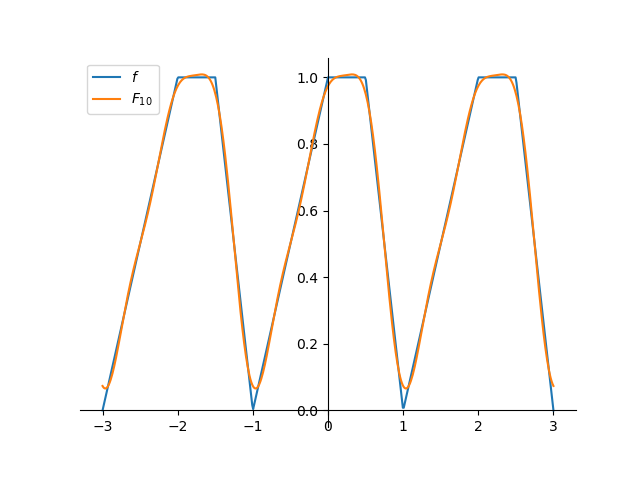

In [8]:
from ipywidgets import interact
p = 3
Nmax = 20
X = np.linspace(-p,p,501)

a,b = FourierCoefs(f,p,Nmax)

fig, ax = plt.subplots()
ax.plot(X,[f(x) for x in X], label = '$f$')

def pplot(N):
    plot(a,b,p,N)
interact(lambda N: plot(a,b,p,N,X), N = (1,Nmax,1))
# interact(pplot, N = (1,Nmax,1))


## 12.2 `scipy.differentiate`: differentiation

We saw that `scipy` could approximate the value of a function. Similarly, it can approximate its derivatives.

Note that numerical differentiation is prone to loss of accuracy:
suppose we can compute an approximation of $f(x)$ with accuracy $\varepsilon$.
If we use the estimate $f'(x) \simeq \frac{f(x+h) - f(x)}{h}$, the accuracy of this estimate for  $f'(x)$ is $\frac{2\varepsilon}{h}$ which diverges as $h \to 0$. Numpy uses better approaches that are *less* prone to error build up, but cannot be error-free.

res:      success: [ True  True ...  True  True]
      status: [0 0 ... 0 0]
          df: [-2.500e-01 -2.522e-01 ...  2.522e-01  2.500e-01]
       error: [ 1.568e-11  1.837e-11 ...  1.837e-11  1.568e-11]
         nit: [3 3 ... 3 3]
        nfev: [13 13 ... 13 13]
           x: [-4.000e+00 -3.920e+00 ...  3.920e+00  4.000e+00]


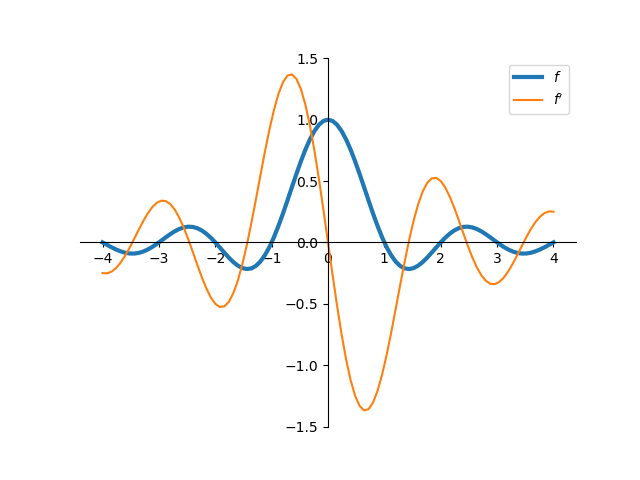

In [10]:
def f(x):
    return np.sinc(x)
X = np.linspace(-4,4,101)

res = scipy.differentiate.derivative(f, X)
print(f"res: {res}")

Fprime = res.df
fig, ax = plt.subplots()
ax.plot(X,f(X), label='$f$', linewidth=3)
ax.plot(X,Fprime,label = "$f'$")
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.legend()